In [27]:
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# 1. Cargar los datos
df = pd.read_csv('house-prices-tp.csv')

In [ ]:
columnas_numericas: list[str] = [col for col in df.columns if col != 'CHAS' and col != 'RAD']

In [23]:
df_limpio = df.dropna(subset=['MEDV'])

In [24]:
df_limpio = df_limpio.dropna(thresh=len(df_limpio.columns)*0.5)

In [25]:
def analizar_outliers(df, columna, target='MEDV'):
    """
    Filtra outliers usando el método IQR y muestra estadísticas 
    comparativas frente a la variable objetivo.
    """
    # Descartar nulos temporalmente para el cálculo
    serie = df[columna].dropna()
    
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    # Filtrar el dataframe original
    df_outliers = df[(df[columna] < limite_inf) | (df[columna] > limite_sup)]
    df_normales = df[(df[columna] >= limite_inf) & (df[columna] <= limite_sup)]
    
    print(f"--- Análisis de Outliers para {columna} ---")
    print(f"Cantidad de outliers detectados: {len(df_outliers)}")
    print(f"Porcentaje del dataset: {(len(df_outliers) / len(serie)) * 100:.2f}%\n")
    
    print("Impacto en la variable Target (MEDV):")
    print(f"MEDV promedio en datos NORMALES: {df_normales[target].mean():.2f} k$")
    print(f"MEDV promedio en OUTLIERS:       {df_outliers[target].mean():.2f} k$")
    print("-" * 45 + "\n")



In [26]:
# 2. Ejecutar análisis para las variables dudosas
for col in ['CRIM', 'ZN', 'B']:
    analizar_outliers(df_limpio, col)

--- Análisis de Outliers para CRIM ---
Cantidad de outliers detectados: 64
Porcentaje del dataset: 12.21%

Impacto en la variable Target (MEDV):
MEDV promedio en datos NORMALES: 23.64 k$
MEDV promedio en OUTLIERS:       15.40 k$
---------------------------------------------

--- Análisis de Outliers para ZN ---
Cantidad de outliers detectados: 54
Porcentaje del dataset: 10.34%

Impacto en la variable Target (MEDV):
MEDV promedio en datos NORMALES: 21.98 k$
MEDV promedio en OUTLIERS:       29.66 k$
---------------------------------------------

--- Análisis de Outliers para B ---
Cantidad de outliers detectados: 86
Porcentaje del dataset: 16.38%

Impacto en la variable Target (MEDV):
MEDV promedio en datos NORMALES: 23.82 k$
MEDV promedio en OUTLIERS:       17.28 k$
---------------------------------------------



## Analisis Outliers CRIM

In [30]:
# Calculamos los cuartiles para la columna 'CRIM'
Q1 = df['CRIM'].quantile(0.25)
Q3 = df['CRIM'].quantile(0.75)
IQR = Q3 - Q1

# Definimos el límite superior (usualmente los outliers de CRIMen se disparan hacia arriba)
limite_superior = Q3 + 1.5 * IQR

# Filtramos el dataset original para quedarnos SOLO con las filas atípicas
df_outliers = df[df['CRIM'] > limite_superior]

# Visualizamos las filas específicas para analizar los datos crudos
display(df_outliers[['CRIM', 'MEDV']].sort_values(by='CRIM', ascending=False))

,CRIM,MEDV
145,88.976200,10.400000
379,88.924127,NaN
397,79.902010,NaN
348,79.412097,28.056450
465,77.502687,15.582743
...,...,...
439,13.359800,12.700000
311,13.075100,20.100000
389,12.802300,10.800000
458,12.510504,28.812426


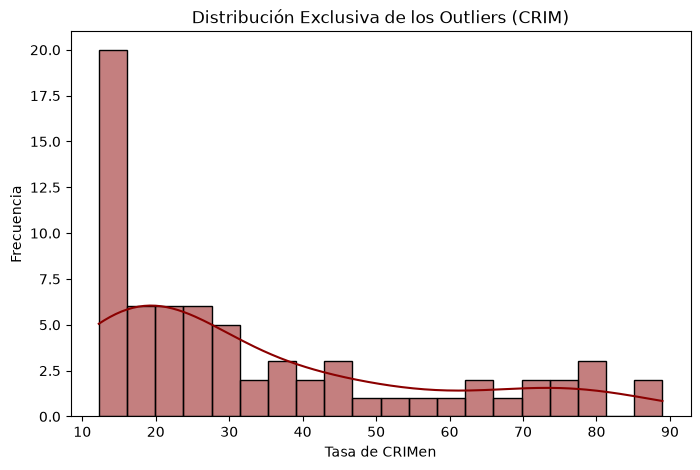

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(df_outliers['CRIM'], bins=20, kde=True, color='darkred')
plt.title('Distribución Exclusiva de los Outliers (CRIM)')
plt.xlabel('Tasa de CRIMen')
plt.ylabel('Frecuencia')
plt.show()

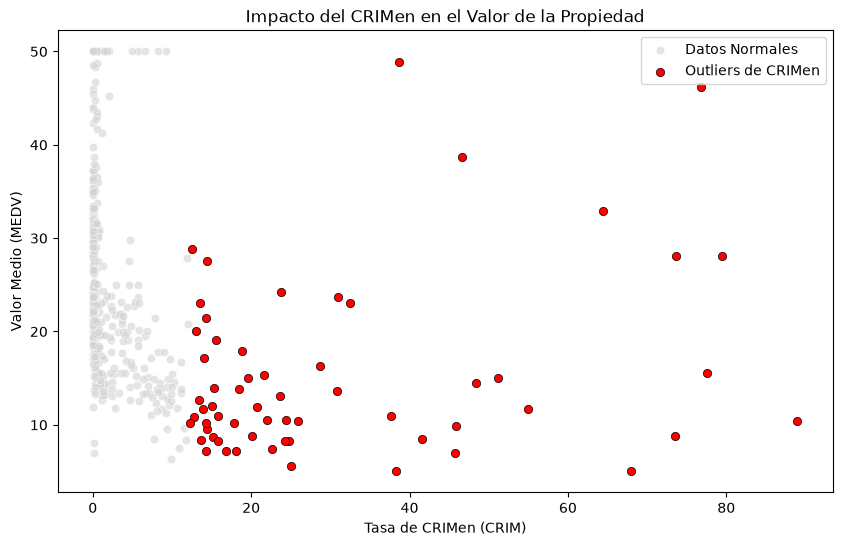

In [32]:
plt.figure(figsize=(10, 6))

# Graficamos el dataset completo en gris claro como contexto
sns.scatterplot(data=df, x='CRIM', y='MEDV', color='lightgrey', alpha=0.6, label='Datos Normales')

# Superponemos nuestros outliers en rojo para ver dónde caen
sns.scatterplot(data=df_outliers, x='CRIM', y='MEDV', color='red', edgecolor='black', label='Outliers de CRIMen')

plt.title('Impacto del CRIMen en el Valor de la Propiedad')
plt.xlabel('Tasa de CRIMen (CRIM)')
plt.ylabel('Valor Medio (MEDV)')
plt.legend()
plt.show()

In [33]:
def analizar_outliers(df, columna_x, columna_y='MEDV'):
    """
    Detecta outliers usando el Rango Intercuartílico (IQR), grafica un scatterplot 
    comparativo y devuelve el DataFrame filtrado.
    """
    # 1. Cálculo de límites
    Q1 = df[columna_x].quantile(0.25)
    Q3 = df[columna_x].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # 2. Filtrado dinámico bidireccional
    # Al usar la condición OR (|), la función detecta automáticamente 
    # si los outliers están por encima del máximo o por debajo del mínimo.
    condicion_outliers = (df[columna_x] < limite_inferior) | (df[columna_x] > limite_superior)
    df_outliers = df[condicion_outliers]
    
    # 3. Visualización cruzada
    plt.figure(figsize=(10, 6))
    
    # Ploteo de datos normales (invirtiendo la condición booleana con ~)
    sns.scatterplot(data=df[~condicion_outliers], x=columna_x, y=columna_y, 
                    color='lightgrey', alpha=0.6, label='Datos Normales')
    
    # Ploteo de outliers
    if not df_outliers.empty:
        sns.scatterplot(data=df_outliers, x=columna_x, y=columna_y, 
                        color='red', edgecolor='black', s=60, label=f'Outliers de {columna_x}')
    
    # Líneas de referencia para visualizar dónde corta el umbral estadístico
    plt.axvline(x=limite_inferior, color='blue', linestyle='--', alpha=0.3)
    plt.axvline(x=limite_superior, color='blue', linestyle='--', alpha=0.3)
    
    plt.title(f'Impacto de {columna_x.upper()} sobre {columna_y.upper()}')
    plt.xlabel(columna_x.upper())
    plt.ylabel(columna_y.upper())
    plt.legend()
    plt.show()
    
    # 4. Reporte en consola
    print(f"--- Análisis de {columna_x.upper()} ---")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Total de outliers detectados: {len(df_outliers)}\n")
    
    return df_outliers

# Ejemplos de uso en tu notebook:
# df_outliers_zn = analizar_outliers(df, 'zn')
# df_outliers_b = analizar_outliers(df, 'b')

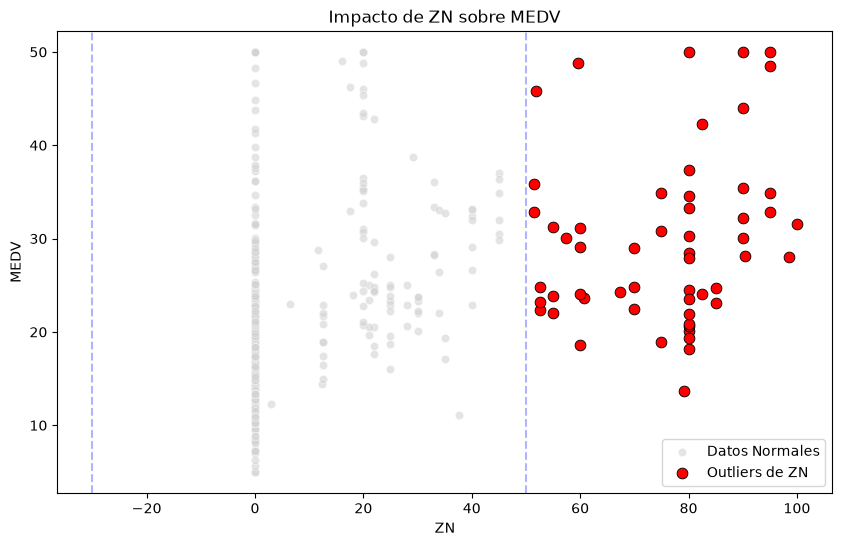

--- Análisis de ZN ---
Límite inferior: -30.00
Límite superior: 50.00
Total de outliers detectados: 60



In [37]:
df_outliers_zn = analizar_outliers(df, 'ZN')

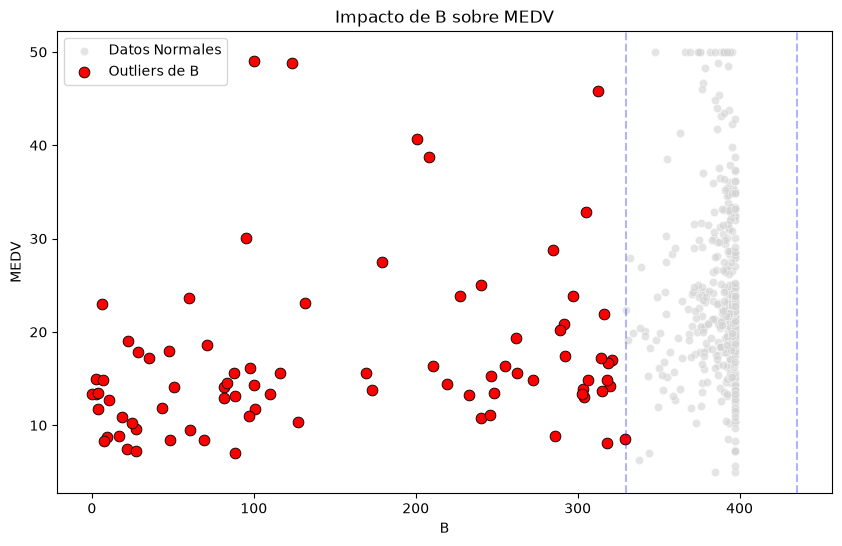

--- Análisis de B ---
Límite inferior: 329.99
Límite superior: 435.43
Total de outliers detectados: 91



In [38]:
df_outliers_b = analizar_outliers(df, 'B')

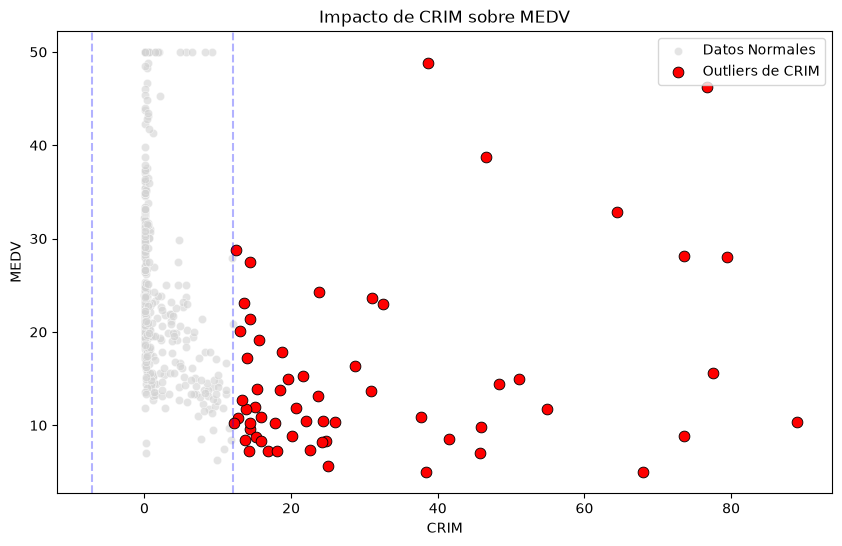

--- Análisis de CRIM ---
Límite inferior: -7.10
Límite superior: 12.05
Total de outliers detectados: 69



In [39]:
df_outliers_crim = analizar_outliers(df, 'CRIM')